## Importing Libraries

In [62]:
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [29]:
# MPS device selection (Mac GPU)

if torch.backends.mps.is_available():
    DEVICE=torch.device("mps")
    print("Using Apple Silicon GPU")
else:
    DEVICE=torch.device("cpu")
    print("Using CPU")

Using Apple Silicon GPU


## Data Loading

In [3]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
# Check for number of rows and columns
df.shape

(50000, 2)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [ ]:
# Checking for null values
df.isnull().sum()

review       0
sentiment    0
dtype: int64

Since no missing values, we don't drop any rows or modify them

In [13]:
df['sentiment'].value_counts(dropna=False)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## Data Preprocessing

In [17]:
# Function to preprocess text
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>','',text) 
    text = re.sub(r'http\S+','',text)
    text = re.sub(r'\s+',' ',text)

    return text.strip()

In [ ]:
# Applying our preprocess function to the entire review column
df['review'] = df['review'].apply(preprocess_text)

In [21]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [ ]:
# Assigning labels to the sentiment column
df['sentiment'] = df['sentiment'].map({"positive":1, "negative":0})

In [23]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. the filming tec...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


## Data Splitting

In [49]:
# Subsetting the dataset to run faster on local laptop
SUBSET = 3000
df = df.sample(SUBSET, random_state=SEED)
texts = df["review"].to_list()
labels = df["sentiment"].to_list()

Tried running a subset of 8000 but the local laptop was taking too long run even one epoch. 

In [50]:
df.shape

(3000, 2)

In [51]:
# train test split
X_tv, X_test, y_tv, y_test = train_test_split(texts, labels, test_size=0.2, random_state=SEED, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.2, random_state=SEED, stratify=y_tv)

## Tokenization

In [52]:
MODEL = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 8
tokenizer = AutoTokenizer.from_pretrained(MODEL)

### Helper Functions

In [53]:
class IMDBDataset(Dataset):
    def __init__(self,texts,labels):
        self.texts=texts
        self.labels=labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self,idx):
        enc=tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":enc["input_ids"].squeeze(0),
            "attention_mask":enc["attention_mask"].squeeze(0),
            "labels":torch.tensor(self.labels[idx])
        }

In [54]:
def train_epoch(model,loader,optimizer,scheduler):
    model.train()
    total_loss=0
    for batch in loader:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(input_ids=ids, attention_mask=mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss/len(loader)

In [55]:
def evaluate(model,loader):
    model.eval()
    preds=[]
    true=[]
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            outputs = model(input_ids=ids, attention_mask=mask)
            predictions = torch.argmax(outputs.logits, dim=1)
            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    return {
        "accuracy":accuracy_score(true,preds),
        "precision":precision_score(true,preds),
        "recall":recall_score(true,preds),
        "f1":f1_score(true,preds)
    },true,preds

In [63]:
def plot_cm(true, preds, title):
    cm = confusion_matrix(true, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative","Positive"]
    )
    
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

In [56]:
train_loader=DataLoader(
    IMDBDataset(X_train,y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader=DataLoader(
    IMDBDataset(X_val,y_val),
    batch_size=BATCH_SIZE,
    num_workers=0

)

test_loader=DataLoader(
    IMDBDataset(X_test,y_test),
    batch_size=BATCH_SIZE,
    num_workers=0
)

## Model Building

In [57]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2).to(DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Fine-Tuning

In [58]:
optimizer = AdamW(model.parameters(), lr=2e-5)
steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(optimizer, 0, steps)

for epoch in range(3):
    loss = train_epoch(model, train_loader, optimizer,scheduler)
    metrics,_,_=evaluate(model, val_loader)
    print(epoch,loss,metrics)

0 0.47793531737600764 {'accuracy': 0.85, 'precision': 0.8771929824561403, 'recall': 0.819672131147541, 'f1': 0.847457627118644}
1 0.27820117481751366 {'accuracy': 0.8541666666666666, 'precision': 0.8107142857142857, 'recall': 0.930327868852459, 'f1': 0.8664122137404581}
2 0.13687424107532328 {'accuracy': 0.8625, 'precision': 0.856, 'recall': 0.8770491803278688, 'f1': 0.8663967611336032}


## Experiment1: Freezing BERT layer and train classifier

In [59]:
model2 = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2).to(DEVICE)

for param in model2.bert.parameters():
    param.requires_grad=False

optimizer2 = AdamW(filter(lambda p:p.requires_grad,model2.parameters()), lr=2e-5)
scheduler2 = get_linear_schedule_with_warmup(optimizer2, 0, steps)

for epoch in range(3):
    loss = train_epoch(model2, train_loader, optimizer2, scheduler2)
    metrics2,_,_ = evaluate(model2, val_loader)
    print(epoch,loss,metrics2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0 0.6948835382858912 {'accuracy': 0.54375, 'precision': 0.5296912114014252, 'recall': 0.9139344262295082, 'f1': 0.6706766917293233}
1 0.6910929888486862 {'accuracy': 0.5458333333333333, 'precision': 0.5311004784688995, 'recall': 0.9098360655737705, 'f1': 0.6706948640483383}
2 0.6904694984356562 {'accuracy': 0.5604166666666667, 'precision': 0.5411471321695761, 'recall': 0.889344262295082, 'f1': 0.6728682170542636}


## Experiment2: Fine-tune last 2 layers of BERT

In [60]:
model3 = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2).to(DEVICE)

for param in model3.parameters():
    param.requires_grad=False

for i in range(10,12):
    for param in model3.bert.encoder.layer[i].parameters():
        param.requires_grad=True

for param in model3.classifier.parameters():
    param.requires_grad=True

optimizer3=AdamW(filter(lambda p:p.requires_grad,model3.parameters()), lr=2e-5)

scheduler3=get_linear_schedule_with_warmup(optimizer3, 0, steps)

for epoch in range(3):
    loss=train_epoch(model3, train_loader, optimizer3, scheduler3)
    metrics3,_,_=evaluate(model3, val_loader)
    print(epoch,loss,metrics3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0 0.5739801828439037 {'accuracy': 0.825, 'precision': 0.8539823008849557, 'recall': 0.7909836065573771, 'f1': 0.8212765957446808}
1 0.36539265491689243 {'accuracy': 0.83125, 'precision': 0.8687782805429864, 'recall': 0.7868852459016393, 'f1': 0.8258064516129032}
2 0.32434867958848673 {'accuracy': 0.8395833333333333, 'precision': 0.8300395256916996, 'recall': 0.860655737704918, 'f1': 0.8450704225352113}


In [61]:
m1,_,_ = evaluate(model, test_loader)
m2,_,_ = evaluate(model2, test_loader)
m3,_,_ = evaluate(model3, test_loader)

results=pd.DataFrame([
    {"Experiment":"Full FT",**m1},
    {"Experiment":"Frozen",**m2},
    {"Experiment":"Last2",**m3}
])
results

,Experiment,accuracy,precision,recall,f1
0,Full FT,0.856667,0.832827,0.898361,0.864353
1,Frozen,0.540000,0.529293,0.859016,0.655000
2,Last2,0.833333,0.817337,0.865574,0.840764


## Analysis of models

Three fine tuning strategies were compared.

Full fine tuning produced the best performance because all BERT layers were allowed to adapt to the dataset. This allowed the model to learn task specific representations.

Freezing BERT layers resulted in the lowest accuracy because only the classifier layer was trained. The pretrained representations were not optimized for the sentiment classification task.

Fine tuning the last two BERT layers produced performance close to full fine tuning while requiring fewer trainable parameters. This shows that higher transformer layers capture task specific features while lower layers capture general language features.

Overall observation:
Full fine tuning gives best performance but partial fine tuning provides a good enough tradeoff between performance and training cost.

| Model | Time Taken(approx) | Cost | Performance |
| -------- | -------- | -------- | -------- |
| Full Fine-Tuning   | 14 min  | High   | Best |
| Freezing BERT and train classifier   | 4 min   | Low   | Poor |
| Fine-Tuning Last2 layers   | 5 min   | Medium   | Good |

### Confusion Matrix

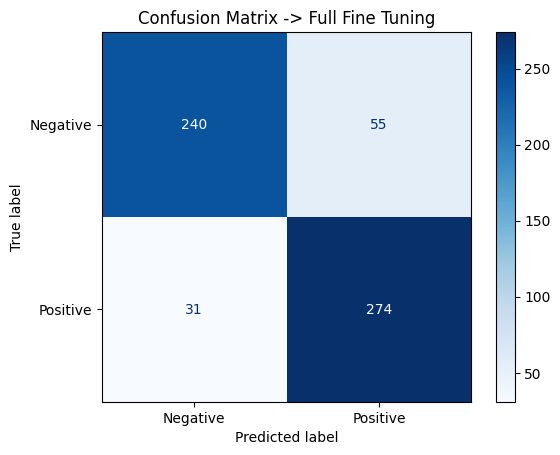

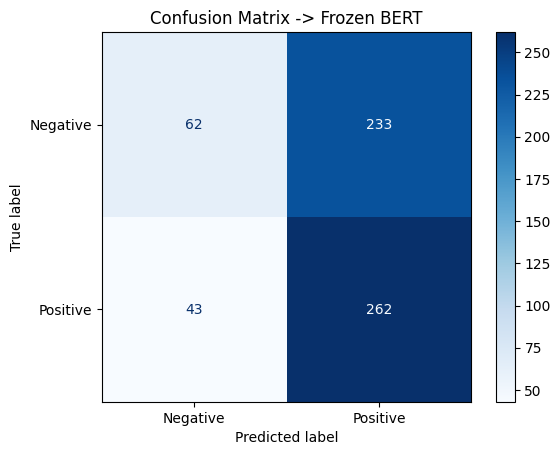

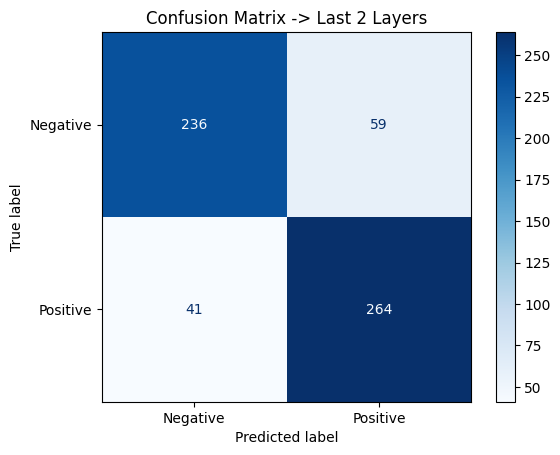

In [64]:
metrics1, true1, preds1 = evaluate(model, test_loader)
plot_cm(true1, preds1, "Confusion Matrix -> Full Fine Tuning")

metrics2, true2, preds2 = evaluate(model2, test_loader)
plot_cm(true2, preds2, "Confusion Matrix -> Frozen BERT")

metrics3, true3, preds3 = evaluate(model3, test_loader)
plot_cm(true3, preds3, "Confusion Matrix -> Last 2 Layers")

Observations(Full Fine-Tuning):
- High TP and TN shows a strong balanced performance

- FN is low (31) showing good recall

- FP is moderate (55) which shows that the model is slightly biased toward positive prediction

Observations(Frozen layers):

- Huge amout of false positives, 233 negatives classified as positive. This means that the classifier predicts positive too often.

- We know from our model evaluation that the accuracy is relatively low at 0.54 and the recall is higher at 0.85.

- This happens because Frozen BERT features are not adapted hence the classifier finds positive features easier to model.

Observations(Last 2 layers):

- Almost similar to the fully fine-tuned model. Relatively smaller drop compared to the full fine-tuned one.

Confusion matrix analysis:

Full fine tuning shows balanced predictions with high true positives and true negatives. The model correctly classifies most reviews with relatively few misclassifications.

Frozen BERT shows a large number of false positives. This indicates that without fine tuning, the pretrained representations are not well adapted to the sentiment classification task and the classifier tends to over-predict the positive class.

Fine tuning the last two layers produces results very close to full fine tuning. This suggests that higher BERT layers capture task specific features while lower layers capture general language features.

Overall, it can be observed that full fine tuning gives the best performance, while partial fine tuning provides a good balance between performance and computational cost.

# BONUS

### Using learning rate scheduler

In [65]:
lrs_model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2).to(DEVICE)
lrs_optimizer = AdamW(lrs_model.parameters(), lr=2e-5)
lrs_epochs = 2
total_steps = len(train_loader) * lrs_epochs
lrs_scheduler = get_linear_schedule_with_warmup(
    lrs_optimizer,
    num_warmup_steps = total_steps//10,
    num_training_steps = total_steps
)

for epoch in range(lrs_epochs):

    loss = train_epoch(
        lrs_model,
        train_loader,
        lrs_optimizer,
        lrs_scheduler
    )

    metrics,_,_ = evaluate(
        lrs_model,
        val_loader
    )

    print("Scheduler Epoch:",epoch)
    print(metrics)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Scheduler Epoch: 0
{'accuracy': 0.85625, 'precision': 0.8755364806866953, 'recall': 0.8360655737704918, 'f1': 0.8553459119496856}
Scheduler Epoch: 1
{'accuracy': 0.8625, 'precision': 0.8588709677419355, 'recall': 0.8729508196721312, 'f1': 0.8658536585365854}


### Implementing Early Stopping

In [66]:
early_model = AutoModelForSequenceClassification.from_pretrained(MODEL,num_labels=2).to(DEVICE)

early_optimizer = AdamW(early_model.parameters(), lr=2e-5)

early_scheduler = get_linear_schedule_with_warmup(
    early_optimizer,
    num_warmup_steps = total_steps//10,
    num_training_steps = total_steps
)

best_f1 = 0
patience = 1
counter = 0
for epoch in range(3):
    loss = train_epoch(early_model, train_loader, early_optimizer, early_scheduler)
    metrics,_,_ = evaluate(early_model, val_loader)
    print("Epoch:",epoch)
    print(metrics)
    if metrics['f1'] > best_f1:
        best_f1 = metrics['f1']
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch: 0
{'accuracy': 0.85, 'precision': 0.8583333333333333, 'recall': 0.8442622950819673, 'f1': 0.8512396694214877}
Epoch: 1
{'accuracy': 0.8666666666666667, 'precision': 0.8688524590163934, 'recall': 0.8688524590163934, 'f1': 0.8688524590163934}
Epoch: 2
{'accuracy': 0.8666666666666667, 'precision': 0.8688524590163934, 'recall': 0.8688524590163934, 'f1': 0.8688524590163934}
Early stopping triggered


### Using DistilBERT

In [67]:
DISTIL_MODEL = "distilbert-base-uncased"
distil_model = AutoModelForSequenceClassification.from_pretrained(DISTIL_MODEL, num_labels=2).to(DEVICE)
distil_optimizer = AdamW(distil_model.parameters(), lr=2e-5)
distil_scheduler = get_linear_schedule_with_warmup(
    distil_optimizer,
    num_warmup_steps = total_steps//10,
    num_training_steps = total_steps
)

for epoch in range(2):
    loss = train_epoch(distil_model, train_loader, distil_optimizer, distil_scheduler)
    metrics,_,_ = evaluate(distil_model, val_loader)
    print("DistilBERT Epoch:",epoch)
    print(metrics)

distil_results,_,_ = evaluate(distil_model, test_loader)
print("DistilBERT Test Results:")
print(distil_results)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Epoch: 0
{'accuracy': 0.84375, 'precision': 0.800711743772242, 'recall': 0.9221311475409836, 'f1': 0.8571428571428571}
DistilBERT Epoch: 1
{'accuracy': 0.8604166666666667, 'precision': 0.852589641434263, 'recall': 0.8770491803278688, 'f1': 0.8646464646464647}
DistilBERT Test Results:
{'accuracy': 0.85, 'precision': 0.8391167192429022, 'recall': 0.8721311475409836, 'f1': 0.8553054662379421}


### Comparison

In [68]:
bonus_results = pd.DataFrame([
    {"Model":"BERT Full FT",**m1},
    {"Model":"BERT Frozen",**m2},
    {"Model":"BERT Last2",**m3},
    {"Model":"DistilBERT",**distil_results}
])

bonus_results

,Model,accuracy,precision,recall,f1
0,BERT Full FT,0.856667,0.832827,0.898361,0.864353
1,BERT Frozen,0.540000,0.529293,0.859016,0.655000
2,BERT Last2,0.833333,0.817337,0.865574,0.840764
3,DistilBERT,0.850000,0.839117,0.872131,0.855305


### Analysis and Insights

Four transformer configurations were compared:

- Full BERT fine tuning produced the best performance because all model layers were adapted to the sentiment classification task.

- DistilBERT achieved performance very close to BERT while requiring less computational cost. This demonstrates that smaller transformer models can provide efficient alternatives with minimal performance loss.

- Freezing BERT layers resulted in significantly lower performance because the pretrained representations were not adapted to the dataset.

- Fine tuning the last two layers produced performance close to full fine tuning, showing that higher transformer layers capture more task-specific features.

Overall:
- Best performance - Full Fine-Tuning
- Best efficiency - DistilBERT
- Best of performance and efficiency - Last2 layers or partial fine-tuning